## Nonlinear roots in geophysics: 2D event location from arrival times

### Problem statement (2D microseismic / earthquake location)

A small seismic event occurs at an unknown 2D location $(x,z)$ at a known origin time $t_0$.
Three receivers at known coordinates $(x_i, z_i)$ record the first-arrival times $(t_i^{obs})$.
Assume a constant P-wave velocity $v$.

For receiver $i$, the travel-time model is

$$
t_i(x,z) = t_0 + \frac{1}{v}\sqrt{(x-x_i)^2 + (z-z_i)^2}.
$$

Define the nonlinear equations (residuals)

$$
f_i(x,z) = \sqrt{(x-x_i)^2 + (z-z_i)^2} - v\,(t_i^{obs}-t_0) = 0.
$$

Each equation represents a circle centered at $(x_i, z_i)$ with radius
$$
r_i = v\,(t_i^{obs}-t_0).
$$

The event location $(x,z)$ is the intersection of the three circles.
We will solve the nonlinear system $f(x,z)=0$ using Newton’s method.


=== Results (2D nonlinear root finding) ===
True location:      x=  800.00 m, z=  900.00 m
Estimated location: x=  800.38 m, z=  900.84 m
Newton iterations:  6

Residuals for used equations (should be ~0): [0. 0.]
Residual for 3rd receiver (validation):      -1.07095245465689


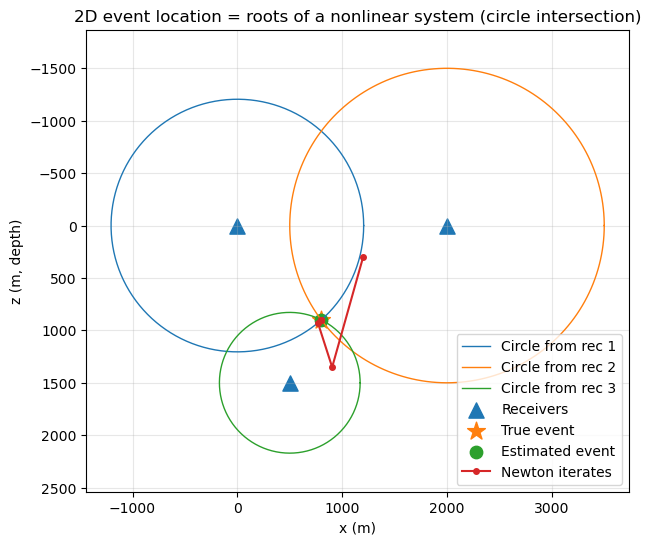


=== Sensitivity to initial guess (same data, same equations) ===
start [100.0, 100.0] -> solution (x,z)=(800.38,900.84), ||f||=2.27e-13
start [2500.0, 200.0] -> solution (x,z)=(800.38,900.84), ||f||=0.00e+00
start [800.0, 2500.0] -> solution (x,z)=(800.38,900.84), ||f||=0.00e+00
start [1500.0, 1200.0] -> solution (x,z)=(800.38,900.84), ||f||=2.27e-13


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Synthetic "geophysical" setup
# -----------------------------
v = 2500.0       # m/s (constant P-wave velocity)
t0 = 0.0         # s (known origin time)

# Receiver coordinates (x,z) in meters (z positive downward)
receivers = np.array([
    [0.0,    0.0],
    [2000.0, 0.0],
    [500.0,  1500.0],
])

# True event location (unknown in practice)
x_true, z_true = 800.0, 900.0

def travel_time(x, z, xi, zi, v, t0):
    return t0 + np.sqrt((x - xi)**2 + (z - zi)**2) / v

# Observed arrival times (optionally add small noise)
np.random.seed(0)
noise_std = 0.0002  # seconds (0.2 ms)
t_obs = np.array([travel_time(x_true, z_true, xi, zi, v, t0) for xi, zi in receivers])
t_obs_noisy = t_obs + np.random.normal(0.0, noise_std, size=t_obs.shape)

# Radii implied by observations
r = v * (t_obs_noisy - t0)

# -----------------------------------
# Nonlinear system: f(x,z) = 0 (2 eq)
# -----------------------------------
# Use only 2 equations for a square system, but we will also check the 3rd as validation.
# (In practice you'd solve an overdetermined problem with least squares.)
use_idx = [0, 1]  # choose two receivers to form a 2x2 system

def f_vec(xz):
    x, z = xz
    f = []
    for i in use_idx:
        xi, zi = receivers[i]
        fi = np.sqrt((x - xi)**2 + (z - zi)**2) - r[i]
        f.append(fi)
    return np.array(f)

def jacobian_fd(xz, h=1e-4):
    """
    Finite-difference Jacobian for f(x,z):
    J_ij = df_i / d(xz_j)
    """
    xz = np.array(xz, dtype=float)
    f0 = f_vec(xz)
    J = np.zeros((len(f0), len(xz)))
    for j in range(len(xz)):
        step = np.zeros_like(xz)
        step[j] = h
        fp = f_vec(xz + step)
        fm = f_vec(xz - step)
        J[:, j] = (fp - fm) / (2*h)
    return J

def newton_solve(xz0, max_iter=20, tol=1e-6, damping=1.0):
    xz = np.array(xz0, dtype=float)
    path = [xz.copy()]
    for k in range(max_iter):
        f = f_vec(xz)
        J = jacobian_fd(xz)
        # Solve J * dx = -f
        try:
            dx = np.linalg.solve(J, -f)
        except np.linalg.LinAlgError:
            print(f"Jacobian singular/ill-conditioned at iter {k}.")
            break

        xz_new = xz + damping * dx
        path.append(xz_new.copy())

        if np.linalg.norm(dx) < tol:
            return xz_new, np.array(path), k+1

        xz = xz_new

    return xz, np.array(path), max_iter

# -----------------------------
# Try Newton from an initial guess
# -----------------------------
xz0 = np.array([1200.0, 300.0])   # initial guess (meters)
sol, path, iters = newton_solve(xz0, max_iter=25, tol=1e-8, damping=1.0)

x_est, z_est = sol

# Evaluate the "unused" 3rd equation as a consistency check
def f_third(x, z):
    i = 2
    xi, zi = receivers[i]
    return np.sqrt((x - xi)**2 + (z - zi)**2) - r[i]

res_used = f_vec(sol)
res_3rd = f_third(x_est, z_est)

print("=== Results (2D nonlinear root finding) ===")
print(f"True location:      x={x_true:8.2f} m, z={z_true:8.2f} m")
print(f"Estimated location: x={x_est:8.2f} m, z={z_est:8.2f} m")
print(f"Newton iterations:  {iters}")
print("")
print("Residuals for used equations (should be ~0):", res_used)
print("Residual for 3rd receiver (validation):     ", res_3rd)

# -----------------------------
# Plot circles and Newton path
# -----------------------------
theta = np.linspace(0, 2*np.pi, 400)

plt.figure(figsize=(7, 6))

# Plot receiver circles
for i, (xi, zi) in enumerate(receivers):
    cx = xi + r[i] * np.cos(theta)
    cz = zi + r[i] * np.sin(theta)
    plt.plot(cx, cz, linewidth=1, label=f"Circle from rec {i+1}")

# Plot receivers, true point, estimated point, and Newton path
plt.scatter(receivers[:,0], receivers[:,1], marker="^", s=120, label="Receivers")
plt.scatter([x_true], [z_true], marker="*", s=180, label="True event")
plt.scatter([x_est], [z_est], marker="o", s=80, label="Estimated event")

plt.plot(path[:,0], path[:,1], "-o", markersize=4, linewidth=1.5, label="Newton iterates")

plt.gca().invert_yaxis()  # depth positive downward (geophysics convention)
plt.xlabel("x (m)")
plt.ylabel("z (m, depth)")
plt.title("2D event location = roots of a nonlinear system (circle intersection)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.show()

# -----------------------------
# Optional: demonstrate sensitivity to initial guess
# -----------------------------
guesses = [
    [100.0,  100.0],
    [2500.0,  200.0],
    [800.0,  2500.0],
    [1500.0, 1200.0],
]

solutions = []
for g in guesses:
    s, p, _ = newton_solve(g, max_iter=30, tol=1e-8, damping=1.0)
    solutions.append((g, s, np.linalg.norm(f_vec(s))))

print("\n=== Sensitivity to initial guess (same data, same equations) ===")
for g, s, fnorm in solutions:
    print(f"start {g} -> solution (x,z)=({s[0]:.2f},{s[1]:.2f}), ||f||={fnorm:.2e}")
